# Recalibrate FGTV methane split to IEA Methane Tracker (Libya 2024)

Per CCD section B.2 / IEA Methane Tracker, Libya's 2024 oil & gas methane emissions are **40.1 Mt CO2e** with the following emission-type split:

| Emission type | IEA share | IEA Mt CO2e |
|---|---|---|
| Venting | 46.5% | 18.65 |
| Incomplete flaring | 24.4% | 9.78 |
| Fugitive (leaks) | 15.8% | 6.34 |
| Other | 13.3% | 5.33 |

Current SISEPUEDE output (BAU, 2024) has the wrong split — fugitive dominates. This notebook scales the production-side FGTV emission factors in the calibrated input CSV so that the model output reproduces the IEA proportions, while preserving the gas mix (CH4/CO2/N2O/NMVOC) and fuel mix (crude/natural_gas/oil/coal) inside each component.

**Inputs**
- `sisepuede_raw_inputs_oilgas_bau_calibrated.csv` (current BAU-calibrated input).
- `decomposed_ssp_output.csv` from the latest run (used only to read current 2024 component values).

**Output**
- `sisepuede_raw_inputs_oilgas_fgtv_recalibrated.csv` (rescaled EFs for production_flaring / production_venting / production_fugitive).

**Validation**
We replot the FGTV components chart by rescaling the existing model output by the scalers (no SISEPUEDE rerun needed for validation). The 13.3% "Other" bucket has no native counterpart in the current output (transmission and distribution emissions are zero), so the visible stacked components will sum to ~87% of 40.1 Mt; the dashed line on the chart reflects that.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

INPUT_DIR = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/input_data')
RUN_DIR   = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-04-24T16;09;46.906938')

SRC_CSV = INPUT_DIR / 'sisepuede_raw_inputs_oilgas_bau_calibrated.csv'
DST_CSV = INPUT_DIR / 'sisepuede_raw_inputs_oilgas_fgtv_recalibrated.csv'

ANCHOR_YEAR = 2024
BASE_YEAR   = 2015
BAU_STRATEGY = 6003
GWP_CH4 = 28.0

# IEA Methane Tracker — Libya 2024
IEA_TOTAL_MT_CO2E = 40.1
IEA_SHARE = {'flaring': 0.244, 'venting': 0.465, 'fugitive': 0.158, 'other': 0.133}
assert abs(sum(IEA_SHARE.values()) - 1.0) < 1e-9
IEA_TARGET = {k: v * IEA_TOTAL_MT_CO2E for k, v in IEA_SHARE.items()}
IEA_TARGET


{'flaring': 9.7844,
 'venting': 18.646500000000003,
 'fugitive': 6.3358,
 'other': 5.3333}

## 1 — Load current input + read 2024 BAU component values from existing output


In [2]:
src = pd.read_csv(SRC_CSV)
print('Input CSV:', SRC_CSV.name, '|', src.shape, '| time periods:', src.time_period.min(), '->', src.time_period.max())

out = pd.read_csv(RUN_DIR / 'decomposed_ssp_output.csv')
att = pd.read_csv(RUN_DIR / 'ATTRIBUTE_PRIMARY.csv')
out = out.merge(att[['primary_id','strategy_id']], on='primary_id')
out['year'] = out['time_period'] + BASE_YEAR

fgtv_cols = [c for c in out.columns if c.startswith('emission_co2e_') and '_fgtv_' in c and c != 'emission_co2e_subsector_total_fgtv']
FLAR_OUT = [c for c in fgtv_cols if '_fgtv_flaring_' in c]
VENT_OUT = [c for c in fgtv_cols if '_fgtv_venting_' in c]
DTP_OUT  = [c for c in fgtv_cols if '_fgtv_dtp_' in c]
print(f'output cols  flaring={len(FLAR_OUT)} venting={len(VENT_OUT)} dtp={len(DTP_OUT)}')

row24 = out[(out.strategy_id == BAU_STRATEGY) & (out.year == ANCHOR_YEAR)].iloc[0]
current = {
    'flaring':  float(row24[FLAR_OUT].sum()),
    'venting':  float(row24[VENT_OUT].sum()),
    'fugitive': float(row24[DTP_OUT].sum()),
}
current['total_visible'] = sum(current.values())
print('\nCurrent BAU 2024 (Mt CO2e):')
for k, v in current.items(): print(f'  {k:>14s}: {v:7.3f}')


Input CSV: sisepuede_raw_inputs_oilgas_bau_calibrated.csv | (36, 2441) | time periods: 0 -> 35
output cols  flaring=12 venting=12 dtp=12

Current BAU 2024 (Mt CO2e):
         flaring:   3.202
         venting:   7.800
        fugitive:  14.839
   total_visible:  25.841


## 2 — Compute scaling factors

Targets are absolute Mt CO2e values from the IEA shares applied to 40.1 Mt. Because EF × production is linear, scaling every production-flaring EF by `s_flar` rescales the modeled flaring CO2e in 2024 (and every other year) by the same factor, while preserving the relative gas/fuel mix.


In [3]:
scalers = {
    'flaring':  IEA_TARGET['flaring']  / current['flaring'],
    'venting':  IEA_TARGET['venting']  / current['venting'],
    'fugitive': IEA_TARGET['fugitive'] / current['fugitive'],
}
summary = pd.DataFrame({
    'current_2024_mt_co2e': [current['flaring'], current['venting'], current['fugitive']],
    'iea_target_mt_co2e':   [IEA_TARGET['flaring'], IEA_TARGET['venting'], IEA_TARGET['fugitive']],
    'iea_share':            [IEA_SHARE['flaring'], IEA_SHARE['venting'], IEA_SHARE['fugitive']],
    'scaler':               [scalers['flaring'], scalers['venting'], scalers['fugitive']],
}, index=['flaring','venting','fugitive'])
summary.round(4)


,current_2024_mt_co2e,iea_target_mt_co2e,iea_share,scaler
flaring,3.2016,9.7844,0.244,3.0561
venting,7.8001,18.6465,0.465,2.3905
fugitive,14.8395,6.3358,0.158,0.4270


## 3 — Apply scalers to the production-side EF columns

We scale every `ef_fgtv_production_<component>_tonne_<gas>_per_m3_fuel_<fuel>` column for the matching component. All gases (CH4, CO2, N2O, NMVOC) and fuels (crude, natural_gas, oil, coal) are scaled by the same factor so the gas mix and fuel mix remain unchanged within each component.


In [4]:
EF_GROUPS = {
    'flaring':  [c for c in src.columns if c.startswith('ef_fgtv_production_flaring_')],
    'venting':  [c for c in src.columns if c.startswith('ef_fgtv_production_venting_')],
    'fugitive': [c for c in src.columns if c.startswith('ef_fgtv_production_fugitive_')],
}
for k, cols in EF_GROUPS.items():
    print(f'{k:>9s}: {len(cols)} EF columns')

dst = src.copy()
for component, cols in EF_GROUPS.items():
    s = scalers[component]
    dst[cols] = dst[cols] * s

# Sanity: a sample EF before/after
sample = 'ef_fgtv_production_venting_tonne_ch4_per_m3_fuel_crude'
print(f'\nsample {sample}\n  before: {src[sample].iloc[0]:.4e}\n  after : {dst[sample].iloc[0]:.4e}\n  ratio : {dst[sample].iloc[0]/src[sample].iloc[0]:.4f} (expected {scalers["venting"]:.4f})')

dst.to_csv(DST_CSV, index=False)
print(f'\nWrote: {DST_CSV}')


  flaring: 14 EF columns
  venting: 10 EF columns
 fugitive: 13 EF columns

sample ef_fgtv_production_venting_tonne_ch4_per_m3_fuel_crude
  before: 1.0218e-02
  after : 2.4426e-02
  ratio : 2.3905 (expected 2.3905)

Wrote: /Users/fabianfuentes/git/ssp_libya/ssp_modeling/input_data/sisepuede_raw_inputs_oilgas_fgtv_recalibrated.csv


## 4 — Validate by rescaling the existing model output

Because the relationship is linear, we can preview the post-rerun chart by multiplying each output column by its component scaler. This avoids a 30-minute SISEPUEDE rerun during calibration. After confirming the proportions look right, switch the manager notebook to read `sisepuede_raw_inputs_oilgas_fgtv_recalibrated.csv` and rerun for the authoritative output.


In [5]:
rescaled = out.copy()
for col in FLAR_OUT: rescaled[col] = rescaled[col] * scalers['flaring']
for col in VENT_OUT: rescaled[col] = rescaled[col] * scalers['venting']
for col in DTP_OUT:  rescaled[col] = rescaled[col] * scalers['fugitive']

comp = rescaled[['strategy_id','year']].copy()
comp['flaring'] = rescaled[FLAR_OUT].sum(axis=1)
comp['venting'] = rescaled[VENT_OUT].sum(axis=1)
comp['dtp']     = rescaled[DTP_OUT].sum(axis=1)
comp['sum_visible'] = comp[['flaring','venting','dtp']].sum(axis=1)

# 2024 sanity check vs IEA
chk = comp[(comp.strategy_id == BAU_STRATEGY) & (comp.year == ANCHOR_YEAR)].iloc[0]
tot24 = chk[['flaring','venting','dtp']].sum()
print(f'BAU 2024 after rescale (Mt CO2e):')
for k, lbl in [('flaring','Flaring'),('venting','Venting'),('dtp','Fugitive')]:
    print(f'  {lbl:>9s}: {chk[k]:7.3f}  ({chk[k]/tot24*100:5.2f}% of visible | {chk[k]/IEA_TOTAL_MT_CO2E*100:5.2f}% of 40.1 Mt IEA)')
print(f'  visible total: {tot24:.3f} Mt CO2e   (target: {IEA_TARGET["flaring"]+IEA_TARGET["venting"]+IEA_TARGET["fugitive"]:.3f}; IEA full total incl. Other: {IEA_TOTAL_MT_CO2E})')


BAU 2024 after rescale (Mt CO2e):
    Flaring:   9.784  (28.14% of visible | 24.40% of 40.1 Mt IEA)
    Venting:  18.646  (53.63% of visible | 46.50% of 40.1 Mt IEA)
   Fugitive:   6.336  (18.22% of visible | 15.80% of 40.1 Mt IEA)
  visible total: 34.767 Mt CO2e   (target: 34.767; IEA full total incl. Other: 40.1)


### Replicate the FGTV components chart with the recalibrated split


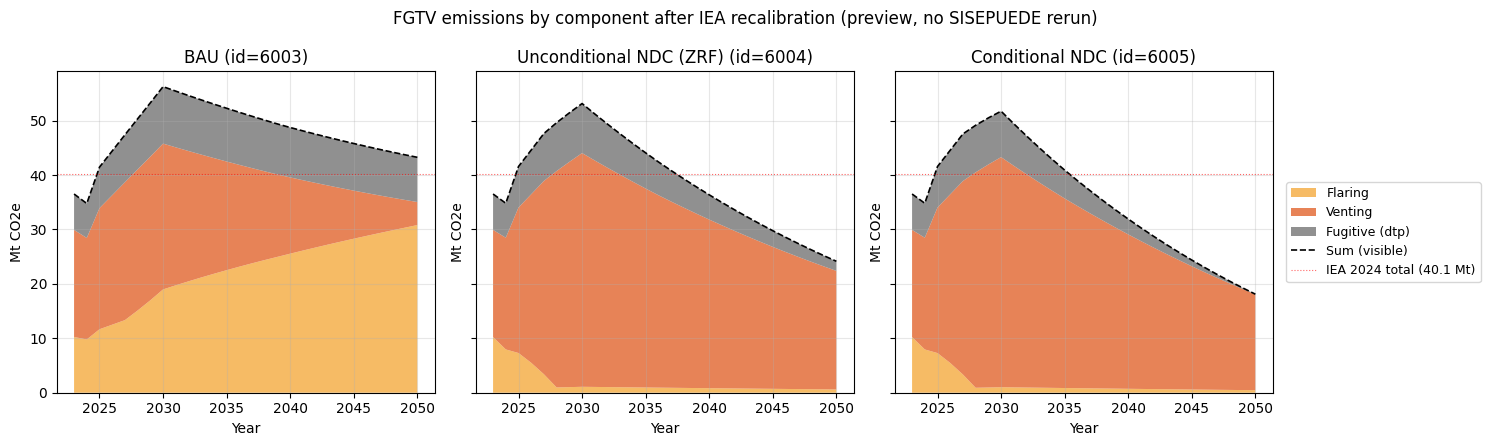

In [6]:
STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}
comp_colors = {'flaring': '#f5b04a', 'venting': '#e36d3a', 'dtp': '#7d7d7d'}
strategies_all = [s for s in [6003, 6004, 6005] if s in comp.strategy_id.unique()]

fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
for ax, sid in zip(axes, strategies_all):
    sub = comp[comp.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['flaring'], sub['venting'], sub['dtp'],
                 labels=['Flaring','Venting','Fugitive (dtp)'],
                 colors=[comp_colors['flaring'], comp_colors['venting'], comp_colors['dtp']], alpha=0.85)
    ax.plot(sub.index, sub['sum_visible'], 'k--', lw=1.2, label='Sum (visible)')
    ax.axhline(IEA_TOTAL_MT_CO2E, color='red', lw=0.8, ls=':', alpha=0.6, label=f'IEA 2024 total ({IEA_TOTAL_MT_CO2E} Mt)')
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.suptitle('FGTV emissions by component after IEA recalibration (preview, no SISEPUEDE rerun)')
plt.tight_layout(); plt.show()


### Component shares in 2024 — recalibrated vs IEA


In [7]:
rows = []
for sid in strategies_all:
    r = comp[(comp.strategy_id == sid) & (comp.year == ANCHOR_YEAR)].iloc[0]
    tot = r['flaring'] + r['venting'] + r['dtp']
    rows.append({
        'strategy_id': sid,
        'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
        'flaring_mt':  round(r['flaring'], 3),
        'venting_mt':  round(r['venting'], 3),
        'fugitive_mt': round(r['dtp'], 3),
        'visible_total_mt': round(tot, 3),
        'flaring_pct_of_iea_total':  round(r['flaring']/IEA_TOTAL_MT_CO2E*100, 2),
        'venting_pct_of_iea_total':  round(r['venting']/IEA_TOTAL_MT_CO2E*100, 2),
        'fugitive_pct_of_iea_total': round(r['dtp']/IEA_TOTAL_MT_CO2E*100, 2),
    })
shares = pd.DataFrame(rows)
print('IEA targets (% of 40.1 Mt): flaring 24.40 | venting 46.50 | fugitive 15.80')
shares


IEA targets (% of 40.1 Mt): flaring 24.40 | venting 46.50 | fugitive 15.80


,strategy_id,strategy_name,flaring_mt,venting_mt,fugitive_mt,visible_total_mt,flaring_pct_of_iea_total,venting_pct_of_iea_total,fugitive_pct_of_iea_total
0,6003,BAU,9.784,18.646,6.336,34.767,24.40,46.50,15.8
1,6004,Unconditional NDC (ZRF),7.954,20.522,6.336,34.813,19.84,51.18,15.8
2,6005,Conditional NDC,7.950,20.527,6.336,34.813,19.83,51.19,15.8


## Notes & next steps

- **The 13.3% "Other" IEA bucket is not represented** in current SISEPUEDE FGTV output (no transmission/distribution emissions in the existing run). The visible stacked total (~34.77 Mt in BAU 2024) sits ~13% below the IEA total of 40.1 Mt by design. If we ever want to materialise it, the cleanest route is to populate `ef_fgtv_transmission_*` and/or `ef_fgtv_distribution_*` so they output ~5.33 Mt CO2e in 2024.
- **Strategies 6004 and 6005 inherit the same input EFs**; their output deltas vs BAU come from transformation YAMLs (gas recovery, venting reduction, etc.). Recalibrating the BAU baseline EFs automatically rebases those strategies too.
- **Next step:** point the manager notebook (e.g. `libya_manager_wb_gas_recovery.ipynb` → `config_files/config.yaml`) at `sisepuede_raw_inputs_oilgas_fgtv_recalibrated.csv` and rerun. Then re-run `reproduce_oilgas_ccd_charts.ipynb` against the new run output to confirm the chart matches this preview.
